In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import xgboost as xgb

import joblib

In [2]:
df = pd.read_csv("parking_features.csv")
df.head()



,SystemCodeNumber,Capacity,Occupancy,LastUpdated,OccupancyRate,OccupancyPercent,AvailableSpaces,Date,Hour,Minute,...,Occupancy_Lag2,Occupancy_Lag3,RollingMean_3,RollingMean_6,RollingStd_6,OccupancyChange,OccupancyRate_Lag1,OccupancyRate_Lag2,TargetOccupancy,TimeDiff
0,BHMBCCMKT01,577,219,2016-10-04 10:59:48,0.379549,37.954939,358,2016-10-04,10,59,...,150.0,107.0,144.666667,106.500000,47.836179,27.0,0.306759,0.259965,247.0,0 days 00:32:59
1,BHMBCCMKT01,577,247,2016-10-04 11:25:47,0.428076,42.807626,330,2016-10-04,11,25,...,177.0,150.0,182.000000,132.833333,59.777644,42.0,0.379549,0.306759,259.0,0 days 00:25:59
2,BHMBCCMKT01,577,259,2016-10-04 11:59:44,0.448873,44.887348,318,2016-10-04,11,59,...,219.0,177.0,214.333333,163.333333,64.158138,28.0,0.428076,0.379549,266.0,0 days 00:33:57
3,BHMBCCMKT01,577,266,2016-10-04 12:29:45,0.461005,46.100520,311,2016-10-04,12,29,...,247.0,219.0,241.666667,193.166667,59.074247,12.0,0.448873,0.428076,269.0,0 days 00:30:01
4,BHMBCCMKT01,577,269,2016-10-04 13:02:48,0.466205,46.620451,308,2016-10-04,13,2,...,259.0,247.0,257.333333,219.666667,47.149408,7.0,0.461005,0.448873,263.0,0 days 00:33:03


In [3]:
df["LastUpdated"] = pd.to_datetime(
    df["LastUpdated"]
)

In [4]:
df.shape

(23293, 30)

In [5]:
df = df.sort_values(
    ["LastUpdated", "SystemCodeNumber"]
).reset_index(drop=True)

In [6]:
df[
    ["SystemCodeNumber", "LastUpdated", "TargetOccupancy"]
].head(20)

,SystemCodeNumber,LastUpdated,TargetOccupancy
0,BHMNCPNHS01,2016-10-04 10:52:49,498.0
1,BHMBCCMKT01,2016-10-04 10:59:48,247.0
2,BHMBCCPST01,2016-10-04 10:59:48,167.0
3,BHMBCCSNH01,2016-10-04 10:59:48,723.0
4,BHMBCCTHL01,2016-10-04 10:59:48,324.0
5,BHMBRCBRG01,2016-10-04 10:59:48,476.0
6,BHMBRCBRG02,2016-10-04 10:59:48,433.0
7,BHMBRCBRG03,2016-10-04 10:59:48,228.0
8,BHMEURBRD01,2016-10-04 10:59:48,464.0
9,BHMEURBRD02,2016-10-04 10:59:48,208.0


In [7]:
target = "TargetOccupancy"

In [8]:
y = df[target]

In [9]:
# slect input features
features = [
    "Capacity",
    "Occupancy",
    "OccupancyRate",
    "AvailableSpaces",

    "Hour",
    "Minute",
    "DayOfWeek",
    "IsWeekend",

    "HourSin",
    "HourCos",
    "DaySin",
    "DayCos",

    "Occupancy_Lag1",
    "Occupancy_Lag2",
    "Occupancy_Lag3",

    "RollingMean_3",
    "RollingMean_6",
    "RollingStd_6",

    "OccupancyChange",

    "OccupancyRate_Lag1",
    "OccupancyRate_Lag2"
]

In [10]:
X = df[features]

In [11]:
X.shape

(23293, 21)

In [12]:
print(df["LastUpdated"].min())
print(df["LastUpdated"].max())

2016-10-04 10:52:49
2016-12-19 16:03:35


In [13]:
train_end = df["LastUpdated"].quantile(0.70)
val_end = df["LastUpdated"].quantile(0.85)

In [14]:
print("Train end:", train_end)
print("Validation end:", val_end)

Train end: 2016-11-25 15:00:56
Validation end: 2016-12-09 08:02:30


In [15]:
# train test split

train_mask = (
    df["LastUpdated"] <= train_end
)

val_mask = (
    (df["LastUpdated"] > train_end) &
    (df["LastUpdated"] <= val_end)
)

test_mask = (
    df["LastUpdated"] > val_end
)

In [16]:
X_train = X.loc[train_mask]
y_train = y.loc[train_mask]

X_val = X.loc[val_mask]
y_val = y.loc[val_mask]

X_test = X.loc[test_mask]
y_test = y.loc[test_mask]

In [17]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (16309, 21)
Validation: (3497, 21)
Test: (3487, 21)


In [18]:
# Verify the dates

print(
    "Train:",
    df.loc[train_mask, "LastUpdated"].min(),
    "→",
    df.loc[train_mask, "LastUpdated"].max()
)

print(
    "Validation:",
    df.loc[val_mask, "LastUpdated"].min(),
    "→",
    df.loc[val_mask, "LastUpdated"].max()
)

print(
    "Test:",
    df.loc[test_mask, "LastUpdated"].min(),
    "→",
    df.loc[test_mask, "LastUpdated"].max()
)

Train: 2016-10-04 10:52:49 → 2016-11-25 15:00:56
Validation: 2016-11-25 15:27:59 → 2016-12-09 08:02:30
Test: 2016-12-09 08:09:33 → 2016-12-19 16:03:35


Model 1 : Naive Baseline

In [19]:
baseline_pred = X_test["Occupancy"]

In [20]:
baseline_mae = mean_absolute_error(
    y_test,
    baseline_pred
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_pred
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_pred
)

In [21]:
print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R²:", baseline_r2)

Baseline MAE: 51.037281330656725
Baseline RMSE: 137.00177299734628
Baseline R²: 0.9053234636902824


In [22]:
# Linear Regression

lr_model = LinearRegression()

In [23]:
lr_model.fit(
    X_train,
    y_train
)

LinearRegression()

In [24]:
lr_pred = lr_model.predict(
    X_test
)

In [25]:
lr_mae = mean_absolute_error(
    y_test,
    lr_pred
)

lr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lr_pred
    )
)

lr_r2 = r2_score(
    y_test,
    lr_pred
)

In [26]:
print("Linear Regression")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R²  :", lr_r2)

Linear Regression
MAE : 44.8612909910179
RMSE: 104.11767551302398
R²  : 0.9453186896363238


In [27]:
# Random Forest
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

In [28]:
rf_model.fit(
    X_train,
    y_train
)

RandomForestRegressor(max_depth=15, n_estimators=200, n_jobs=-1,
                      random_state=42)

In [29]:
rf_pred = rf_model.predict(
    X_test
)

In [30]:
rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

In [31]:
print("Random Forest")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest
MAE : 21.15323315150707
RMSE: 60.553583860365514
R²  : 0.9815043461108262


In [32]:
# XGBoost

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

In [33]:
xgb_model.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)

In [34]:
xgb_pred = xgb_model.predict(
    X_test
)

In [35]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_pred
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_pred
    )
)

xgb_r2 = r2_score(
    y_test,
    xgb_pred
)

In [36]:
print("XGBoost")
print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)
print("R²  :", xgb_r2)

XGBoost
MAE : 20.64505910811877
RMSE: 55.969218992471774
R²  : 0.9841988578763892


In [37]:
# Compare all models

results = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],

    "MAE": [
        baseline_mae,
        lr_mae,
        rf_mae,
        xgb_mae
    ],

    "RMSE": [
        baseline_rmse,
        lr_rmse,
        rf_rmse,
        xgb_rmse
    ],

    "R2": [
        baseline_r2,
        lr_r2,
        rf_r2,
        xgb_r2
    ]
})

In [38]:
results.sort_values(
    "MAE"
)

,Model,MAE,RMSE,R2
3,XGBoost,20.645059,55.969219,0.984199
2,Random Forest,21.153233,60.553584,0.981504
1,Linear Regression,44.861291,104.117676,0.945319
0,Naive Baseline,51.037281,137.001773,0.905323


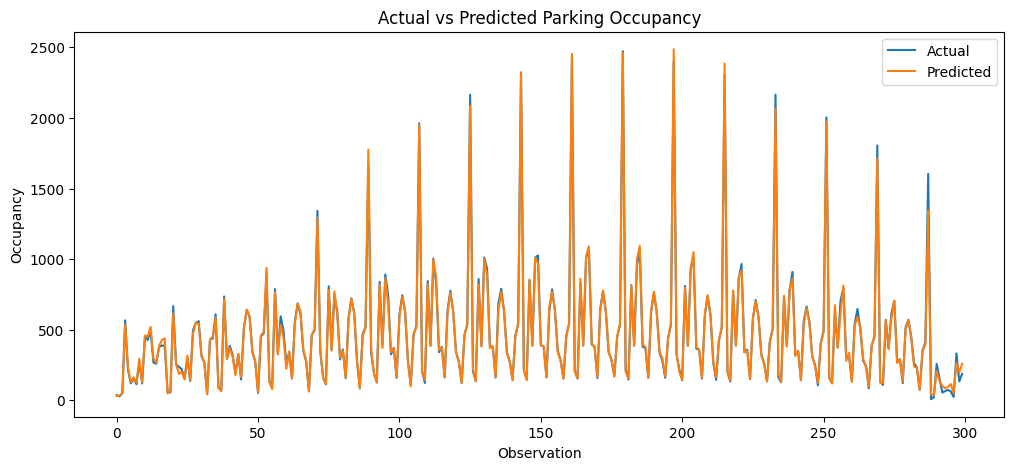

In [39]:
# Visualize predictions
plt.figure(figsize=(12, 5))

plt.plot(
    y_test.values[:300],
    label="Actual"
)

plt.plot(
    xgb_pred[:300],
    label="Predicted"
)

plt.xlabel("Observation")
plt.ylabel("Occupancy")
plt.title("Actual vs Predicted Parking Occupancy")

plt.legend()

plt.show()

In [41]:
# Feature importance

importance = pd.Series(
    xgb_model.feature_importances_,
    index=features
).sort_values(
    ascending=False
)

importance

,0
Occupancy,0.496648
Occupancy_Lag1,0.239618
HourCos,0.057765
Occupancy_Lag2,0.044888
Hour,0.029465
OccupancyChange,0.029269
OccupancyRate,0.015170
HourSin,0.014824
OccupancyRate_Lag2,0.012203
Minute,0.012137


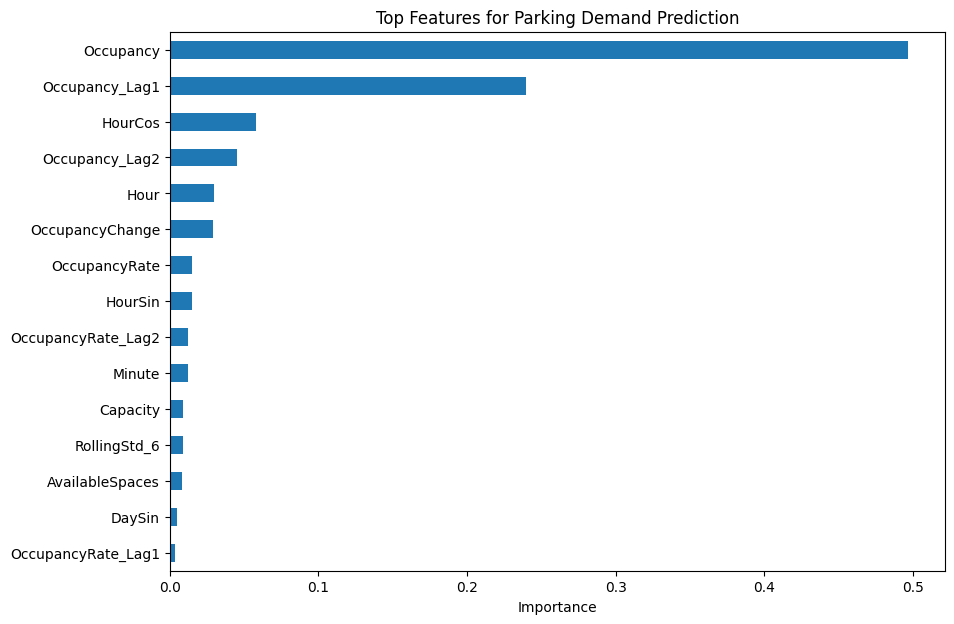

In [42]:
plt.figure(figsize=(10, 7))

importance.head(15).sort_values().plot(
    kind="barh"
)

plt.xlabel("Importance")
plt.title("Top Features for Parking Demand Prediction")

plt.show()

In [43]:
joblib.dump(
    xgb_model,
    "demand_model.pkl"
)

['demand_model.pkl']